In [1]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install matplotlib pandas numpy scikit-learn seaborn pillow

Looking in indexes: https://download.pytorch.org/whl/cu118



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import json
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset          # ← Subset replaces random_split

from sklearn.metrics import classification_report, confusion_matrix

print("All imports OK")
print("PyTorch version:", torch.__version__)

All imports OK
PyTorch version: 2.7.1+cpu


In [10]:
DATASET_PATH = r"D:\Git Hub IMP\car_type_classification"

IMG_SIZE    = 224      # ResNet18 expects 224×224
BATCH_SIZE  = 32
EPOCHS      = 15       # more epochs → better convergence
LR          = 1e-3     # initial LR for unfrozen head (higher is fine; scheduler will anneal it)
LR_BACKBONE = 1e-4     # lower LR for pretrained backbone layers
VAL_SPLIT   = 0.2      # 80/20 train/val
SEED        = 42

# Reproducibility — fixes random behaviour in numpy, python, and torch
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


C:\Users\knowl\AppData\Local\Temp\ipykernel_20876\3585668415.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_counts, x="Class", y="Image Count", palette="Blues_d")


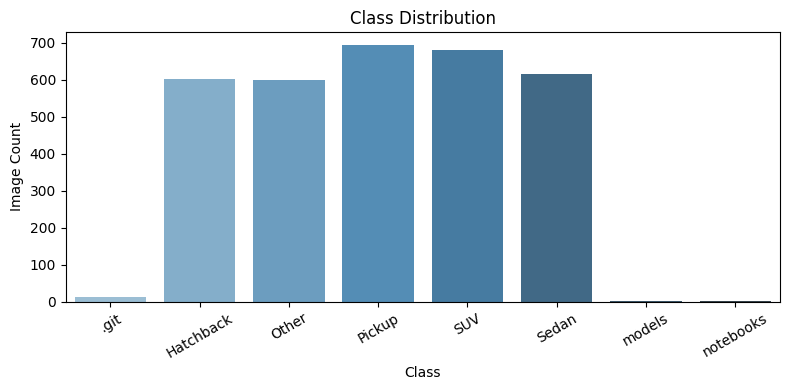

    Class  Image Count
     .git           12
Hatchback          602
    Other          600
   Pickup          693
      SUV          680
    Sedan          616
   models            1
notebooks            1


In [11]:
classes = sorted([
    c for c in os.listdir(DATASET_PATH)
    if os.path.isdir(os.path.join(DATASET_PATH, c))
])

class_counts = {
    cls: len(os.listdir(os.path.join(DATASET_PATH, cls)))
    for cls in classes
}

df_counts = pd.DataFrame(class_counts.items(), columns=["Class", "Image Count"])

plt.figure(figsize=(8, 4))
sns.barplot(data=df_counts, x="Class", y="Image Count", palette="Blues_d")
plt.title("Class Distribution")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(df_counts.to_string(index=False))

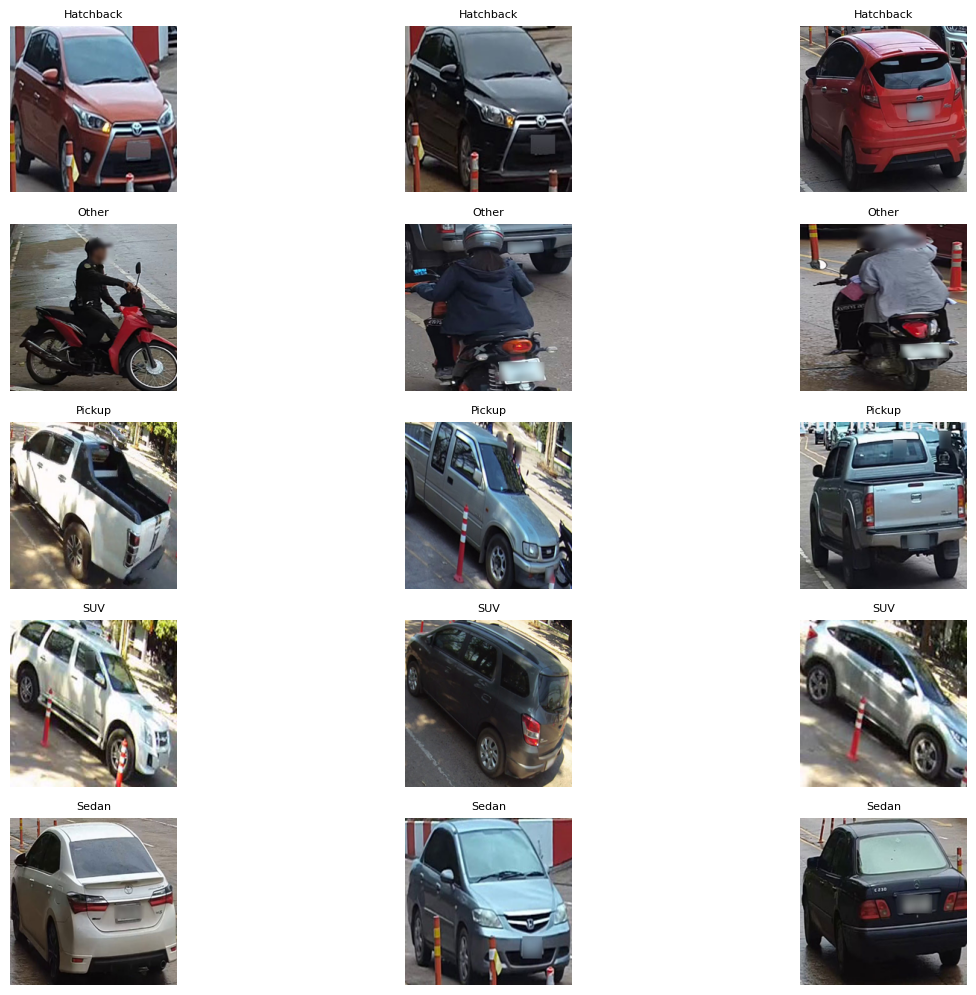

In [5]:
plt.figure(figsize=(12, 2 * len(classes)))
plot_idx = 1

for cls in classes:
    cls_path = os.path.join(DATASET_PATH, cls)
    images   = [f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg','.jpeg','.png'))][:3]

    for img_name in images:
        img = Image.open(os.path.join(cls_path, img_name)).convert("RGB")  # force RGB
        img = img.resize((IMG_SIZE, IMG_SIZE))
        plt.subplot(len(classes), 3, plot_idx)
        plt.imshow(img)
        plt.title(cls, fontsize=8)
        plt.axis("off")
        plot_idx += 1

plt.tight_layout()
plt.show()

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.05),
    transforms.RandomGrayscale(p=0.05),         # rare grayscale → more robust
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print("Transforms defined.")

Transforms defined.


In [13]:
# ── Block 7 — Fixed Train/Val Split ────────────────────────────────────

# Explicitly define only car class folders (ignores .git, models, notebooks etc.)
CAR_CLASSES = ["Hatchback", "Other", "Pickup", "Sedan", "SUV"]

class FilteredImageFolder(datasets.ImageFolder):
    def find_classes(self, directory):
        classes = [d for d in os.listdir(directory)
                   if os.path.isdir(os.path.join(directory, d))
                   and d in CAR_CLASSES]
        classes.sort()
        class_to_idx = {cls: i for i, cls in enumerate(classes)}
        return classes, class_to_idx

# Load TWICE — same images, different transforms, no shared reference
train_dataset_full = FilteredImageFolder(root=DATASET_PATH, transform=train_transform)
val_dataset_full   = FilteredImageFolder(root=DATASET_PATH, transform=val_transform)

class_names = train_dataset_full.classes
num_classes  = len(class_names)
total        = len(train_dataset_full)

print("Classes found:", class_names)
print(f"Total images:  {total}")

# Shuffle indices once with fixed seed → reproducible split every run
torch.manual_seed(SEED)
indices     = torch.randperm(total).tolist()
train_size  = int((1 - VAL_SPLIT) * total)

train_indices = indices[:train_size]
val_indices   = indices[train_size:]

# Each Subset points to its own dataset object → transforms fully isolated
train_dataset = Subset(train_dataset_full, train_indices)
val_dataset   = Subset(val_dataset_full,   val_indices)

print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images")

Classes found: ['Hatchback', 'Other', 'Pickup', 'SUV', 'Sedan']
Total images:  3191
Train: 2552 images | Val: 639 images


In [14]:
num_workers = 4 if os.name != 'nt' else 0   # Windows can struggle with >0 workers in notebooks

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,           # deterministic order → consistent metrics each epoch
    num_workers=num_workers,
    pin_memory=True
)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Train batches: 80 | Val batches: 20


In [15]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Replace the classifier head
num_features = model.fc.in_features
model.fc = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(256, num_classes)
)

# --- Stage 1: freeze backbone ---
for name, param in model.named_parameters():
    if "fc" not in name:          # freeze everything except our new head
        param.requires_grad = False

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total_p:,}")

Trainable params: 132,613 / 11,309,125


In [16]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)   # label smoothing → less overconfident predictions

# Only optimise the head in Stage 1
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR,
    weight_decay=1e-4
)

scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

print("Loss, optimizer, and scheduler ready.")

Loss, optimizer, and scheduler ready.


In [17]:
UNFREEZE_EPOCH = 5       # after this epoch, unfreeze backbone with lower LR

train_losses, val_losses         = [], []
train_accuracies, val_accuracies = [], []
best_val_acc  = 0.0
best_model_wts = None

for epoch in range(1, EPOCHS + 1):

    # ── Stage 2: unfreeze backbone ──────────────────────────────────────
    if epoch == UNFREEZE_EPOCH + 1:
        print("\n>>> Unfreezing backbone for fine-tuning...")
        for param in model.parameters():
            param.requires_grad = True

        # Rebuild optimizer: backbone gets a lower LR than the head
        optimizer = optim.Adam([
            {"params": model.fc.parameters(),  "lr": LR},
            {"params": [p for n, p in model.named_parameters() if "fc" not in n], "lr": LR_BACKBONE}
        ], weight_decay=1e-4)
        scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS - UNFREEZE_EPOCH, eta_min=1e-6)

    # ── Training phase ──────────────────────────────────────────────────
    model.train()
    running_loss = 0.0
    correct = total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted  = outputs.max(1)
        total        += labels.size(0)
        correct      += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc  = correct / total

    # ── Validation phase ────────────────────────────────────────────────
    model.eval()
    val_running_loss = 0.0
    val_correct = val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            loss           = criterion(outputs, labels)

            val_running_loss += loss.item()
            _, predicted      = outputs.max(1)
            val_total        += labels.size(0)
            val_correct      += predicted.eq(labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_acc  = val_correct / val_total

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc  = val_acc
        best_model_wts = {k: v.clone() for k, v in model.state_dict().items()}
        print(f"  ✓ New best val acc: {best_val_acc:.4f} — weights saved")

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch:02d}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
        f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}"
    )

# Restore best weights before evaluation
model.load_state_dict(best_model_wts)
print(f"\nTraining complete. Best Val Acc: {best_val_acc:.4f}")

c:\Users\knowl\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


  ✓ New best val acc: 0.7402 — weights saved
Epoch [01/15] Train Loss: 1.2770  Train Acc: 0.5125  Val Loss: 0.9553  Val Acc: 0.7402
  ✓ New best val acc: 0.7872 — weights saved
Epoch [02/15] Train Loss: 1.0868  Train Acc: 0.6332  Val Loss: 0.8877  Val Acc: 0.7872
  ✓ New best val acc: 0.8185 — weights saved
Epoch [03/15] Train Loss: 1.0312  Train Acc: 0.6650  Val Loss: 0.8421  Val Acc: 0.8185
Epoch [04/15] Train Loss: 0.9783  Train Acc: 0.6983  Val Loss: 0.8173  Val Acc: 0.8013
Epoch [05/15] Train Loss: 0.9801  Train Acc: 0.6908  Val Loss: 0.8216  Val Acc: 0.8013

>>> Unfreezing backbone for fine-tuning...
  ✓ New best val acc: 0.9624 — weights saved
Epoch [06/15] Train Loss: 0.7388  Train Acc: 0.8472  Val Loss: 0.5165  Val Acc: 0.9624
  ✓ New best val acc: 0.9828 — weights saved
Epoch [07/15] Train Loss: 0.5554  Train Acc: 0.9495  Val Loss: 0.4563  Val Acc: 0.9828
  ✓ New best val acc: 0.9890 — weights saved
Epoch [08/15] Train Loss: 0.4894  Train Acc: 0.9804  Val Loss: 0.4434  Val Ac

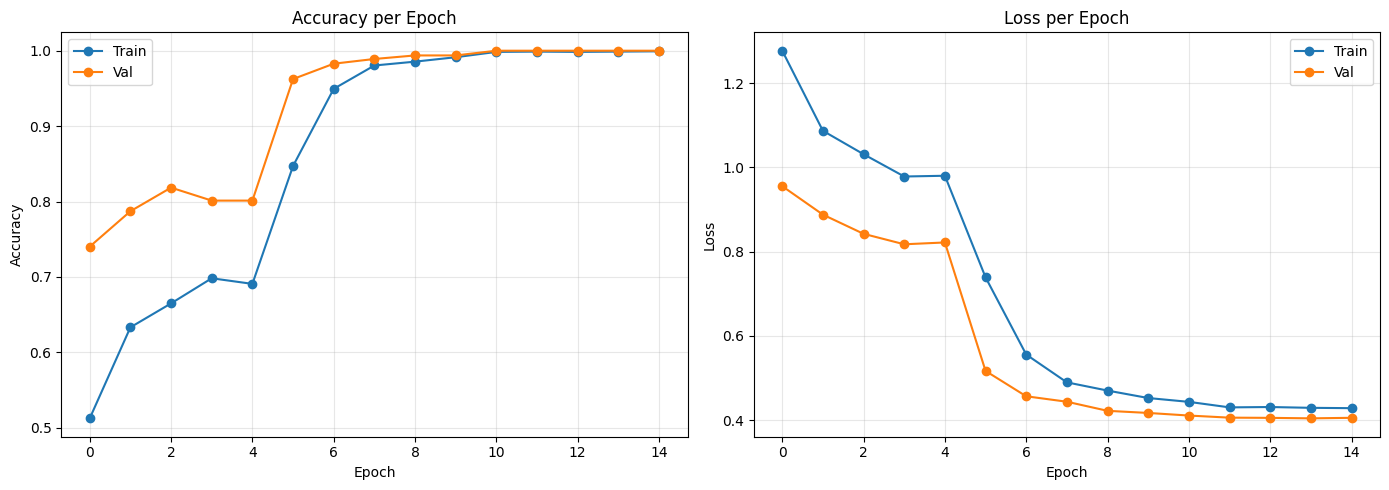

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(train_accuracies, label="Train", marker="o")
axes[0].plot(val_accuracies,   label="Val",   marker="o")
axes[0].set_title("Accuracy per Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_losses, label="Train", marker="o")
axes[1].plot(val_losses,   label="Val",   marker="o")
axes[1].set_title("Loss per Epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Classification Report:
              precision    recall  f1-score   support

   Hatchback     1.0000    1.0000    1.0000       112
       Other     1.0000    1.0000    1.0000       122
      Pickup     1.0000    1.0000    1.0000       159
         SUV     1.0000    1.0000    1.0000       121
       Sedan     1.0000    1.0000    1.0000       125

    accuracy                         1.0000       639
   macro avg     1.0000    1.0000    1.0000       639
weighted avg     1.0000    1.0000    1.0000       639



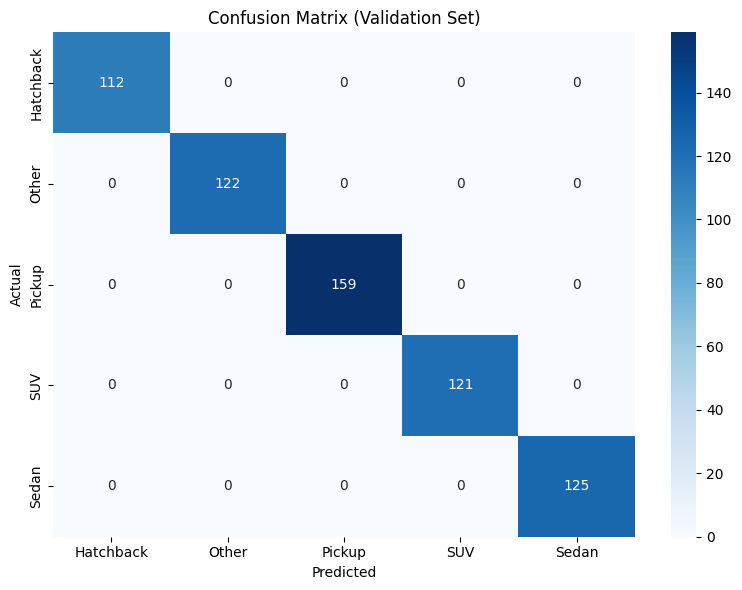

In [19]:
model.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs        = model(images)
        _, predicted   = outputs.max(1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=class_names,
    yticklabels=class_names,
    cmap="Blues"
)
plt.title("Confusion Matrix (Validation Set)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

c:\Users\knowl\AppData\Local\Programs\Python\Python313\Lib\site-packages\torch\utils\data\dataloader.py:665: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


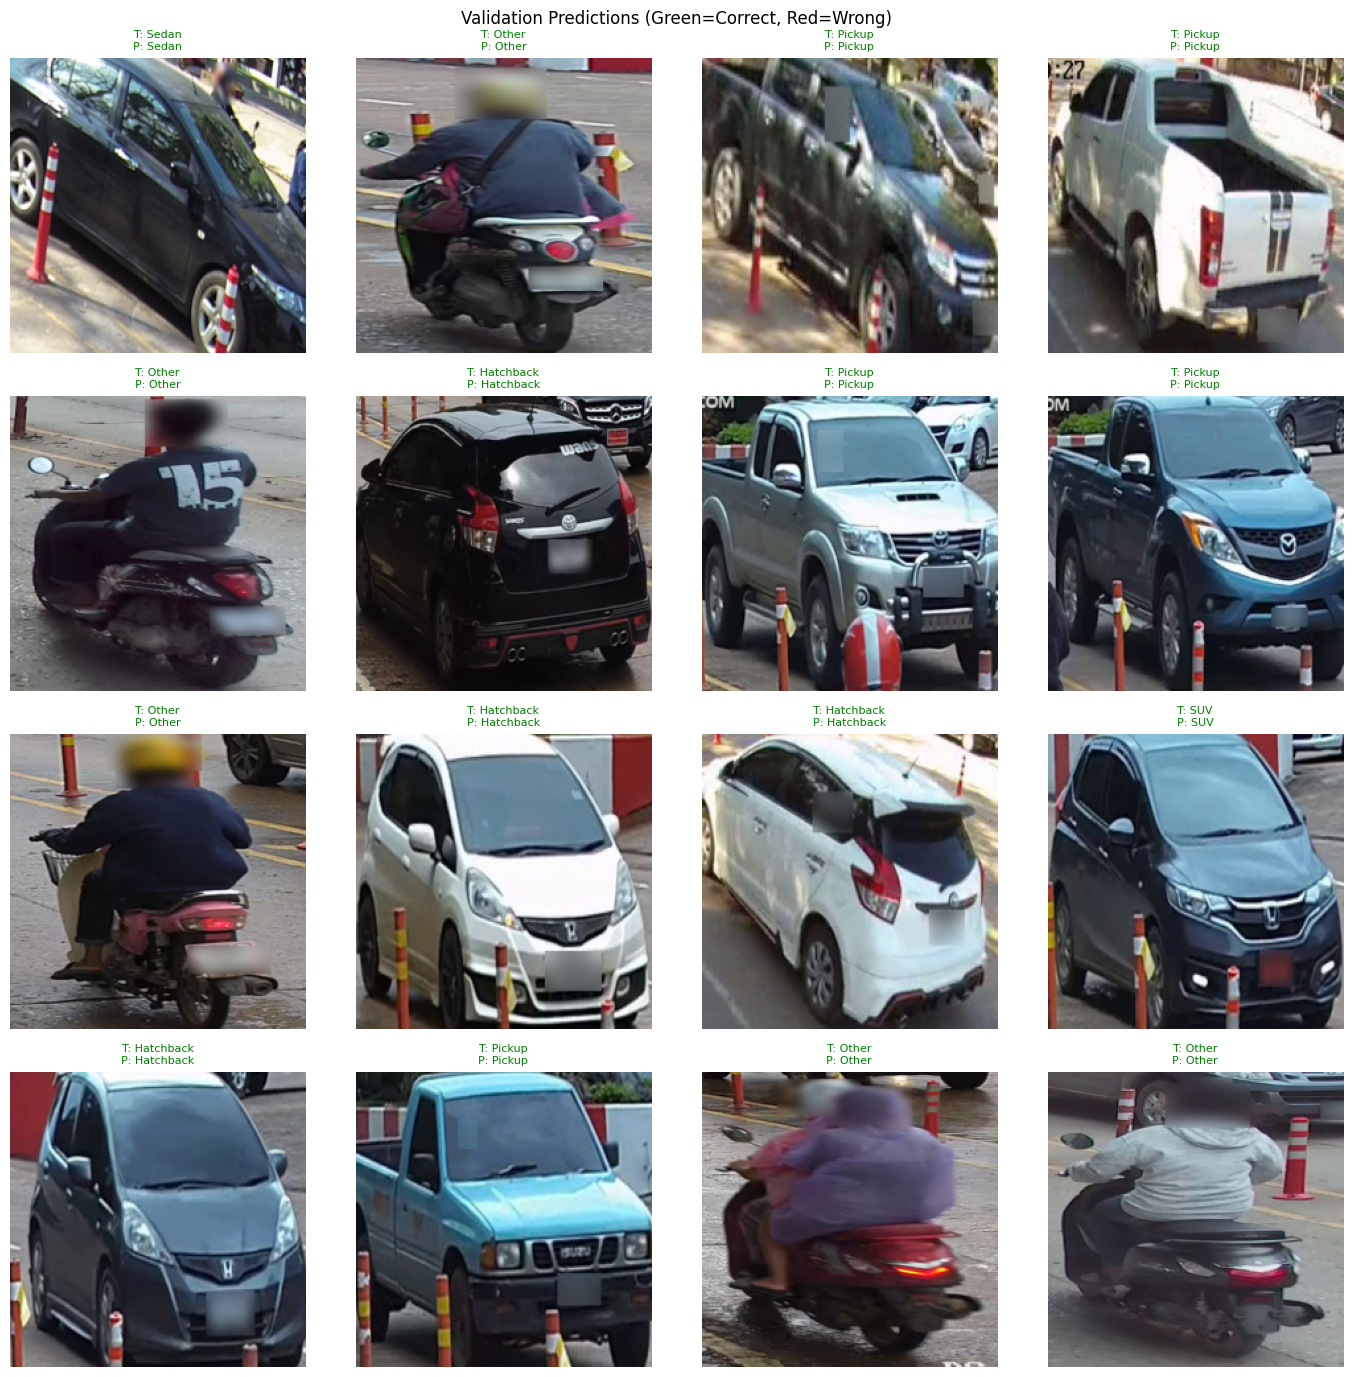

In [20]:
IMAGENET_MEAN_T = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
IMAGENET_STD_T  = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denormalize(tensor):
    """Undo ImageNet normalisation for display."""
    return (tensor * IMAGENET_STD_T + IMAGENET_MEAN_T).clamp(0, 1)

model.eval()
images_shown = 0
n_show = 16

fig, axes = plt.subplots(4, 4, figsize=(14, 14))
axes = axes.flatten()

with torch.no_grad():
    for images, labels in val_loader:
        images_dev = images.to(device)
        outputs    = model(images_dev)
        _, preds   = outputs.max(1)

        for i in range(images.size(0)):
            if images_shown >= n_show:
                break
            img = denormalize(images[i]).permute(1, 2, 0).numpy()
            ax  = axes[images_shown]
            ax.imshow(img)
            true_lbl = class_names[labels[i]]
            pred_lbl = class_names[preds[i].cpu()]
            colour   = "green" if true_lbl == pred_lbl else "red"
            ax.set_title(f"T: {true_lbl}\nP: {pred_lbl}", color=colour, fontsize=8)
            ax.axis("off")
            images_shown += 1

        if images_shown >= n_show:
            break

plt.suptitle("Validation Predictions (Green=Correct, Red=Wrong)", fontsize=12)
plt.tight_layout()
plt.show()

In [21]:
# Block 15 — Save Model & Class Names

MODEL_PATH  = r"D:\Git Hub IMP\car_type_classification\models\vehicle_type_resnet18_v2.pth"
LABELS_PATH = r"D:\Git Hub IMP\car_type_classification\models\class_names_v2.json"

torch.save(model.state_dict(), MODEL_PATH)

with open(LABELS_PATH, "w") as f:
    json.dump(class_names, f)

print(f"Model saved  → {MODEL_PATH}")
print(f"Labels saved → {LABELS_PATH}")
print(f"Best Val Accuracy: {best_val_acc:.4f}")

Model saved  → D:\Git Hub IMP\car_type_classification\models\vehicle_type_resnet18_v2.pth
Labels saved → D:\Git Hub IMP\car_type_classification\models\class_names_v2.json
Best Val Accuracy: 1.0000
